# 10 — Анализ ошибок модели (Глава 3 ВКР)

Раздел 3.6 ВКР: анализ ошибок по типам, per-CWE, по уверенности, по уровням severity. Используем `VulnerabilityPredictor` для прогона по всем 972 записям test set с CVSS v4.0.

### Артефакты
- `reports/error_analysis/worst_cases.csv`
- `reports/error_analysis/per_cwe_metrics.csv`
- `reports/severity_transitions.csv`
- `reports/figures/per_cwe_analysis.png`
- `reports/figures/confidence_analysis.png`


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

FIG_DIR = ROOT / 'reports' / 'figures'
ERR_DIR = ROOT / 'reports' / 'error_analysis'
ERR_DIR.mkdir(parents=True, exist_ok=True)

## 1. Прогон модели по test set

In [2]:
from src.inference import VulnerabilityPredictor
from src.data_preparation.cvss_vector_parser import (
    V4_METRIC_ORDER, V4_LABEL_MAPS, parse_v4_vector,
)

predictor = VulnerabilityPredictor(
    model_path=str(ROOT / 'models' / 'final_model.pt'),
    config_path=str(ROOT / 'configs' / 'train.yaml'),
    cwe_vocab_path=str(ROOT / 'data' / 'processed' / 'cwe_vocab.json'),
    device='cpu',
)
test_df = pd.read_parquet(ROOT / 'data' / 'processed' / 'test.parquet')
test_v4 = test_df[test_df['cvss_v4_vector'].notna()].reset_index(drop=True)
print(f'Test v4: {len(test_v4)} записей')

C:\Users\Артём\Desktop\diplom\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5933.59it/s]


[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Test v4: 972 записей


In [3]:
items = []
for _, r in test_v4.iterrows():
    items.append({
        'description': r['d_ru'] if pd.notna(r['d_ru']) else r['d_en'],
        'description_ru': r['d_ru'] if pd.notna(r['d_ru']) else None,
        'cwe_id': r['cwe_id'],
        'epss': float(r['epss']) if pd.notna(r['epss']) else None,
        'kev': int(r['kev']) if pd.notna(r['kev']) else None,
        'exploit': int(r['exploit']) if pd.notna(r['exploit']) else None,
    })

import time
t0 = time.time()
predictions = predictor.predict_batch(items, batch_size=16)
print(f'Inference time: {time.time() - t0:.1f} сек')

Inference time: 211.8 сек


In [4]:
BASE_METRICS = [m for m in V4_METRIC_ORDER if m != 'E']

rows = []
for r, pred in zip(test_v4.itertuples(), predictions):
    true_metrics = parse_v4_vector(r.cvss_v4_vector)
    n_correct = sum(true_metrics[m] == pred['metrics'][m] for m in BASE_METRICS)
    conf_avg = float(np.mean([pred['confidence'][m] for m in V4_METRIC_ORDER]))
    rows.append({
        'cve_id': r.cve_id,
        'cwe_id': r.cwe_id,
        'description': (r.d_ru if isinstance(r.d_ru, str) and r.d_ru else r.d_en) or '',
        'true_vector': r.cvss_v4_vector.split('/CR:')[0],
        'pred_vector': pred['vector'],
        'true_score': None,
        'pred_score': pred['score'],
        'true_severity': None,
        'pred_severity': pred['severity'],
        'num_metrics_correct': n_correct,
        'confidence_avg': conf_avg,
        **{f'true_{m}': true_metrics[m] for m in V4_METRIC_ORDER},
        **{f'pred_{m}': pred['metrics'][m] for m in V4_METRIC_ORDER},
        **{f'conf_{m}': pred['confidence'][m] for m in V4_METRIC_ORDER},
    })
results = pd.DataFrame(rows)

from src.cvss_calculator import CVSSCalculator
calc = CVSSCalculator()
for i, row in results.iterrows():
    metrics = {
        m: (row[f'true_{m}'] if isinstance(row[f'true_{m}'], str)
            else ('A' if m == 'E' else 'N'))
        for m in V4_METRIC_ORDER
    }
    s, sev, _ = calc.calculate(metrics)
    results.at[i, 'true_score'] = s
    results.at[i, 'true_severity'] = sev

results['score_abs_error'] = (results['pred_score'] - results['true_score']).abs()
print('Shape:', results.shape)
print(f'mean num_metrics_correct = {results.num_metrics_correct.mean():.2f} / 11')
print(f'mean score MAE = {results.score_abs_error.mean():.2f}')
results.head()

Shape: (972, 48)
mean num_metrics_correct = 8.98 / 11
mean score MAE = 1.42


,cve_id,cwe_id,description,true_vector,pred_vector,true_score,pred_score,true_severity,pred_severity,num_metrics_correct,...,conf_PR,conf_UI,conf_VC,conf_VI,conf_VA,conf_SC,conf_SI,conf_SA,conf_E,score_abs_error
0,CVE-2024-52324,CWE-242,Уязвимость операционной системы Ruijie Reyee O...,AV:N/AC:L/AT:P/PR:N/UI:N/VC:H/VI:H/VA:H/SC:N/S...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:N/VC:H/VI:H/VA...,9.2,9.3,Critical,Critical,10,...,0.962138,0.931854,0.935534,0.918258,0.950309,0.995889,0.993991,0.970289,0.985938,0.1
1,CVE-2024-28050,CWE-284,Уязвимость графических драйверов микропрограмм...,CVSS:4.0/AV:L/AC:L/AT:N/PR:L/UI:P/VC:N/VI:N/VA...,CVSS:4.0/AV:L/AC:L/AT:N/PR:L/UI:N/VC:N/VI:N/VA...,5.1,6.8,Medium,Medium,10,...,0.852187,0.881675,0.955274,0.824679,0.943183,0.996591,0.993736,0.962962,0.606116,1.7
2,CVE-2024-9277,CWE-1333,A vulnerability classified as problematic was ...,CVSS:4.0/AV:A/AC:L/AT:N/PR:L/UI:N/VC:N/VI:N/VA...,CVSS:4.0/AV:N/AC:L/AT:N/PR:L/UI:N/VC:L/VI:N/VA...,5.1,5.3,Medium,Medium,8,...,0.679026,0.993683,0.771537,0.801970,0.664306,0.997093,0.997113,0.998179,0.999068,0.2
3,CVE-2024-11303,CWE-22,The pathname of the root directory to a Restri...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:N/VC:H/VI:N/VA...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:N/VC:H/VI:H/VA...,8.7,9.9,High,Critical,8,...,0.830192,0.882624,0.819950,0.939497,0.968232,0.921603,0.779029,0.568324,0.990383,1.2
4,CVE-2025-32827,CWE-89,Уязвимость программного обеспечения для управл...,AV:N/AC:L/AT:N/PR:L/UI:N/VC:H/VI:H/VA:H/SC:N/S...,CVSS:4.0/AV:N/AC:L/AT:N/PR:L/UI:N/VC:H/VI:H/VA...,8.7,8.7,High,High,11,...,0.674412,0.994348,0.993044,0.979309,0.985990,0.998648,0.998286,0.996718,0.502475,0.0


## Раздел 1. Худшие предсказания по числу неверных метрик

Топ-20 записей с минимальным `num_metrics_correct`. Сохраняем в `reports/error_analysis/worst_cases.csv` для приложения к ВКР.

In [5]:
worst = results.nsmallest(20, 'num_metrics_correct')[
    ['cve_id', 'cwe_id', 'description', 'true_vector', 'pred_vector',
     'num_metrics_correct', 'true_score', 'pred_score',
     'true_severity', 'pred_severity', 'confidence_avg']
].copy()
worst['description'] = worst['description'].str.slice(0, 200)
worst.to_csv(ERR_DIR / 'worst_cases.csv', index=False, encoding='utf-8-sig')
worst.head(10)

,cve_id,cwe_id,description,true_vector,pred_vector,num_metrics_correct,true_score,pred_score,true_severity,pred_severity,confidence_avg
439,CVE-2024-10668,CWE-434,Уязвимость функции OnPayloadReceived() утилиты...,AV:A/AC:H/AT:N/PR:L/UI:A/VC:L/VI:H/VA:L/SC:L/S...,CVSS:4.0/AV:N/AC:L/AT:P/PR:N/UI:N/VC:L/VI:N/VA...,2,5.9,7.0,Medium,High,0.654428
723,CVE-2024-38271,CWE-404,Уязвимость функции для передачи данных Nearby ...,AV:A/AC:H/AT:P/PR:L/UI:A/VC:H/VI:L/VA:L/SC:H/S...,CVSS:4.0/AV:N/AC:L/AT:P/PR:N/UI:N/VC:N/VI:N/VA...,2,5.9,8.2,Medium,High,0.806643
969,CVE-2024-5436,CWE-704,Type confusion in Snapchat LensCore could lead...,CVSS:4.0/AV:N/AC:H/AT:P/PR:L/UI:P/VC:L/VI:H/VA...,CVSS:4.0/AV:L/AC:L/AT:N/PR:N/UI:N/VC:N/VI:H/VA...,2,7.3,7.0,High,High,0.763696
125,CVE-2025-43877,CWE-79,Уязвимость компонента WebGUI микропрограммного...,AV:N/AC:L/AT:N/PR:L/UI:A/VC:N/VI:N/VA:N/SC:L/S...,CVSS:4.0/AV:N/AC:L/AT:P/PR:N/UI:N/VC:H/VI:H/VA...,3,4.8,9.2,Medium,Critical,0.812098
148,CVE-2024-13058,CWE-269,An issue exists in SoftIron HyperCloud\n where...,CVSS:4.0/AV:N/AC:L/AT:N/PR:L/UI:A/VC:N/VI:N/VA...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:N/VC:L/VI:L/VA...,3,4.8,6.9,Medium,Medium,0.648253
223,CVE-2024-12801,CWE-918,Server-Side Request Forgery (SSRF) in SaxEvent...,CVSS:4.0/AV:L/AC:L/AT:P/PR:L/UI:P/VC:L/VI:N/VA...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:A/VC:L/VI:N/VA...,3,2.4,5.1,Low,Medium,0.727018
331,CVE-2024-38499,CWE-269,Уязвимость команд caf encrypt и sd_acmd encryp...,AV:L/AC:H/AT:P/PR:L/UI:A/VC:H/VI:H/VA:H/SC:H/S...,CVSS:4.0/AV:L/AC:L/AT:N/PR:L/UI:N/VC:H/VI:L/VA...,3,7.3,6.9,High,Medium,0.815974
596,CVE-2024-1721,CWE-347,Improper Verification of Cryptographic Signatu...,CVSS:4.0/AV:L/AC:H/AT:P/PR:H/UI:A/VC:N/VI:H/VA...,CVSS:4.0/AV:N/AC:L/AT:P/PR:N/UI:N/VC:H/VI:H/VA...,3,5.6,9.4,Medium,Critical,0.735508
611,CVE-2024-10534,CWE-346,Origin Validation Error vulnerability in Datap...,CVSS:4.0/AV:A/AC:L/AT:N/PR:L/UI:P/VC:H/VI:H/VA...,CVSS:4.0/AV:N/AC:L/AT:N/PR:N/UI:N/VC:H/VI:L/VA...,3,8.6,8.8,High,High,0.747662
746,CVE-2022-3474,CWE-522,A bad credential handling in the remote assets...,CVSS:4.0/AV:A/AC:L/AT:N/PR:L/UI:N/VC:L/VI:N/VA...,CVSS:4.0/AV:N/AC:L/AT:P/PR:L/UI:N/VC:N/VI:H/VA...,3,5.1,7.2,Medium,High,0.604728


In [6]:
# Какие именно метрики ошибаются у худших случаев?
diff = []
for _, row in results.nsmallest(50, 'num_metrics_correct').iterrows():
    for m in BASE_METRICS:
        if row[f'true_{m}'] != row[f'pred_{m}']:
            diff.append(m)
wrong_metric_counts = pd.Series(diff).value_counts()
print('Какие метрики чаще всего ошибаются в худших 50 случаях:')
print(wrong_metric_counts)

Какие метрики чаще всего ошибаются в худших 50 случаях:
SC    42
SI    42
VA    41
VI    37
VC    35
PR    32
UI    32
SA    31
AT    23
AV    18
AC    14
Name: count, dtype: int64


## Раздел 2. Per-CWE анализ

In [7]:
min_count = 10
cwe_counts = results['cwe_id'].value_counts()
good_cwe = cwe_counts[cwe_counts >= min_count].index.tolist()
per_cwe = (results[results['cwe_id'].isin(good_cwe)]
           .groupby('cwe_id')
           .agg(n=('cve_id', 'count'),
                mean_correct=('num_metrics_correct', 'mean'),
                score_mae=('score_abs_error', 'mean'),
                accuracy=('num_metrics_correct', lambda s: (s == 11).mean()))
           .sort_values('mean_correct', ascending=False))
per_cwe.round(3).to_csv(ERR_DIR / 'per_cwe_metrics.csv', encoding='utf-8-sig')
print(f'CWE с ≥{min_count} примерами: {len(per_cwe)}')
print('\nTop-10 best:')
print(per_cwe.head(10).round(3).to_string())
print('\nTop-10 worst:')
print(per_cwe.tail(10).round(3).to_string())

CWE с ≥10 примерами: 20

Top-10 best:
           n  mean_correct score_mae  accuracy
cwe_id                                        
CWE-89   109        10.422  0.492661     0.679
CWE-74    46        10.065  1.080435     0.457
CWE-476   14         9.857  0.957143     0.429
CWE-121   16         9.625   1.05625     0.312
CWE-266   15         9.533  0.633333     0.267
CWE-119   93         9.473   1.65914     0.376
CWE-125   20         9.450      1.29     0.350
CWE-434   19         9.421  0.889474     0.421
CWE-77    34         9.294  1.691176     0.324
CWE-20    41         9.220  1.521951     0.341

Top-10 worst:
          n  mean_correct score_mae  accuracy
cwe_id                                       
CWE-200  16         9.125      1.05     0.125
CWE-306  10         9.000      1.78     0.200
CWE-79   87         8.943  1.165517     0.287
CWE-120  17         8.882  1.652941     0.118
CWE-404  12         8.667  1.283333     0.250
CWE-78   26         8.654  1.038462     0.154
CWE-287  12    

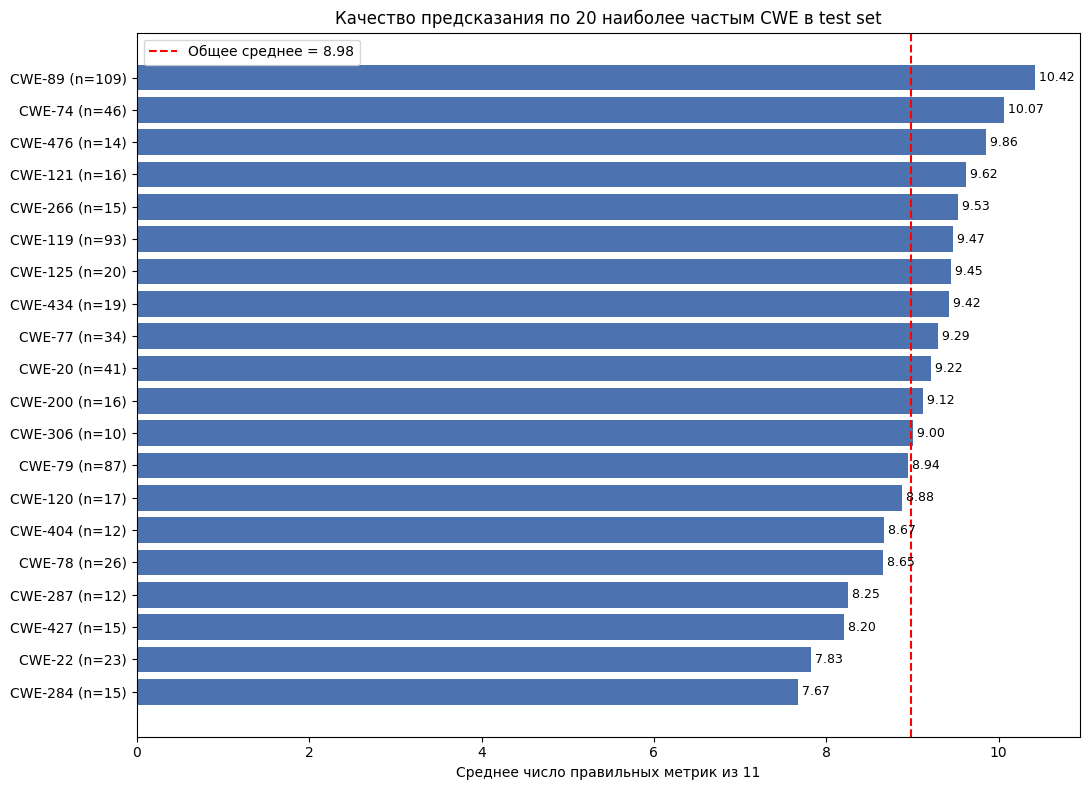

In [8]:
top20 = cwe_counts.head(20).index.tolist()
subset = per_cwe.loc[per_cwe.index.intersection(top20)].sort_values('mean_correct')

fig, ax = plt.subplots(figsize=(11, 8))
y = np.arange(len(subset))
bars = ax.barh(y, subset['mean_correct'], color='#4c72b0')
ax.set_yticks(y)
ax.set_yticklabels([f'{c} (n={int(subset.loc[c, "n"])})' for c in subset.index])
ax.set_xlabel('Среднее число правильных метрик из 11')
ax.set_title('Качество предсказания по 20 наиболее частым CWE в test set')
ax.axvline(results.num_metrics_correct.mean(), color='red', linestyle='--',
           label=f'Общее среднее = {results.num_metrics_correct.mean():.2f}')
ax.legend()
for bar, val in zip(bars, subset['mean_correct']):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}',
            va='center', fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / 'per_cwe_analysis.png')
plt.show()

## Раздел 3. Анализ confidence модели

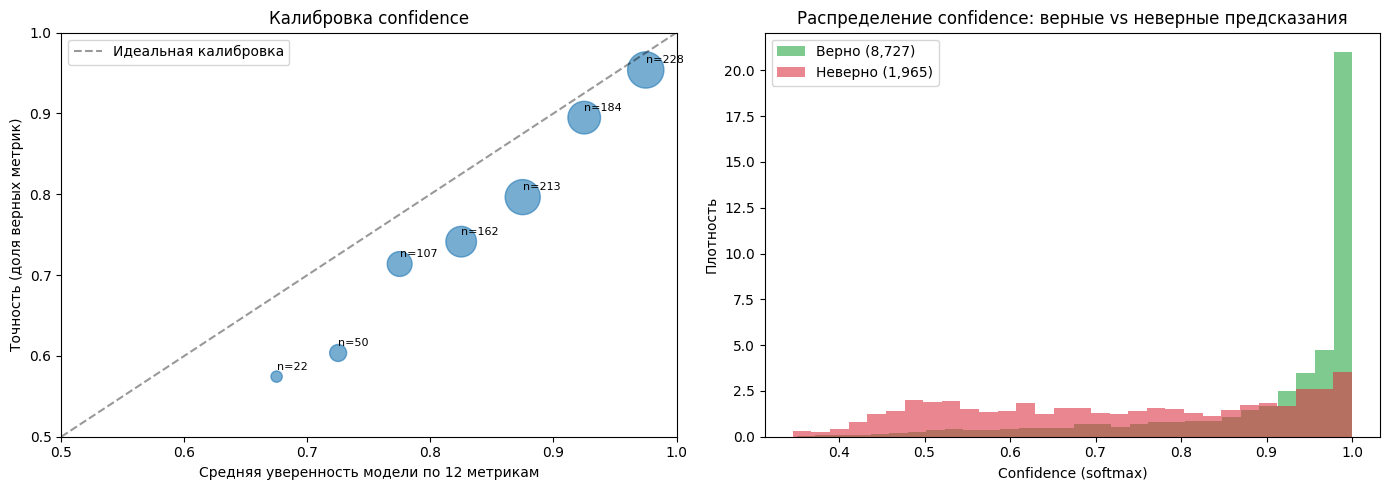

Средний confidence на верных: 0.905
Средний confidence на неверных: 0.725


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (а) корреляция средней уверенности с числом правильных метрик
buckets = pd.cut(results['confidence_avg'],
                 bins=np.arange(0.5, 1.01, 0.05))
calibration = results.groupby(buckets, observed=True).agg(
    accuracy=('num_metrics_correct', 'mean'),
    n=('cve_id', 'count'),
).dropna()
x_centers = [(b.left + b.right) / 2 for b in calibration.index]
axes[0].scatter(x_centers, calibration['accuracy'] / 11,
                s=calibration['n'] * 3, alpha=0.6, color='#1f77b4')
for xc, ac, n in zip(x_centers, calibration['accuracy'] / 11, calibration['n']):
    axes[0].annotate(f'n={n}', (xc, ac), fontsize=8,
                     textcoords='offset points', xytext=(0, 5))
axes[0].plot([0.5, 1.0], [0.5, 1.0], 'k--', alpha=0.4, label='Идеальная калибровка')
axes[0].set_xlabel('Средняя уверенность модели по 12 метрикам')
axes[0].set_ylabel('Точность (доля верных метрик)')
axes[0].set_title('Калибровка confidence')
axes[0].legend()
axes[0].set_xlim(0.5, 1.0)
axes[0].set_ylim(0.5, 1.0)

# (б) распределение confidence для верных/неверных метрик
right_confs = []
wrong_confs = []
for _, row in results.iterrows():
    for m in BASE_METRICS:
        c = row[f'conf_{m}']
        if row[f'true_{m}'] == row[f'pred_{m}']:
            right_confs.append(c)
        else:
            wrong_confs.append(c)
axes[1].hist(right_confs, bins=30, alpha=0.6,
             label=f'Верно ({len(right_confs):,})', color='#28a745', density=True)
axes[1].hist(wrong_confs, bins=30, alpha=0.6,
             label=f'Неверно ({len(wrong_confs):,})', color='#dc3545', density=True)
axes[1].set_xlabel('Confidence (softmax)')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Распределение confidence: верные vs неверные предсказания')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / 'confidence_analysis.png')
plt.show()

import numpy as np
print(f'Средний confidence на верных: {np.mean(right_confs):.3f}')
print(f'Средний confidence на неверных: {np.mean(wrong_confs):.3f}')

In [10]:
# Топ-10 уверенных, но неверных предсказаний (confidence > 0.9)
high_conf_wrong = []
for _, row in results.iterrows():
    for m in BASE_METRICS:
        if row[f'true_{m}'] != row[f'pred_{m}'] and row[f'conf_{m}'] > 0.9:
            high_conf_wrong.append({
                'cve_id': row['cve_id'], 'cwe_id': row['cwe_id'],
                'metric': m, 'true': row[f'true_{m}'],
                'pred': row[f'pred_{m}'], 'confidence': row[f'conf_{m}'],
                'description': row['description'][:200],
            })
high_conf_wrong = pd.DataFrame(high_conf_wrong).sort_values(
    'confidence', ascending=False
).head(10)
high_conf_wrong.to_csv(ERR_DIR / 'high_confidence_errors.csv',
                       index=False, encoding='utf-8-sig')
print(f'Всего ошибок с confidence > 0.9: {((results.iloc[:, results.columns.str.startswith("conf_")]).values > 0.9).sum()}')
high_conf_wrong[['cve_id', 'metric', 'true', 'pred', 'confidence']]

Всего ошибок с confidence > 0.9: 7431


,cve_id,metric,true,pred,confidence
222,CVE-2025-32072,SA,L,N,0.999765
157,CVE-2025-9574,SA,H,N,0.999682
436,CVE-2024-22033,SC,L,N,0.999586
340,CVE-2026-0652,SC,L,N,0.999560
341,CVE-2026-0652,SI,L,N,0.999327
388,CVE-2025-1864,SC,H,N,0.999326
134,CVE-2024-5991,SC,H,N,0.999256
221,CVE-2025-32072,SI,L,N,0.999093
18,CVE-2023-32188,SC,H,N,0.998989
203,CVE-2024-6558,SA,L,N,0.998925


## Раздел 4. Анализ severity-ошибок

Какие переходы `true → pred` встречаются чаще всего.

In [11]:
with open(ROOT / 'reports' / 'test_evaluation.json', 'r', encoding='utf-8') as f:
    eval_data = json.load(f)
sev_conf = eval_data['severity_confusion']

transitions = []
for true_sev, preds in sev_conf.items():
    for pred_sev, n in preds.items():
        if n > 0:
            transitions.append({
                'true': true_sev, 'pred': pred_sev, 'count': n,
                'type': ('exact' if true_sev == pred_sev
                          else 'overestimate' if ['None','Low','Medium','High','Critical'].index(pred_sev) >
                                ['None','Low','Medium','High','Critical'].index(true_sev)
                          else 'underestimate'),
            })
trans_df = pd.DataFrame(transitions).sort_values('count', ascending=False)
trans_df.to_csv(ROOT / 'reports' / 'severity_transitions.csv',
                index=False, encoding='utf-8-sig')
trans_df

,true,pred,count,type
7,Medium,Medium,338,exact
13,High,High,241,exact
8,Medium,High,65,overestimate
18,Critical,Critical,54,exact
12,High,Medium,48,underestimate
14,High,Critical,42,overestimate
17,Critical,High,37,underestimate
6,Medium,Low,33,underestimate
9,Medium,Critical,22,overestimate
1,Low,Low,22,exact


In [12]:
# Краткая статистика смещений severity
tot = trans_df['count'].sum()
exact = trans_df[trans_df['type'] == 'exact']['count'].sum()
over = trans_df[trans_df['type'] == 'overestimate']['count'].sum()
under = trans_df[trans_df['type'] == 'underestimate']['count'].sum()
print(f'Точные предсказания severity: {exact}/{tot} ({exact/tot:.1%})')
print(f'Завышения (overestimate):    {over}/{tot} ({over/tot:.1%})')
print(f'Занижения (underestimate):   {under}/{tot} ({under/tot:.1%})')
print('\nКрупнейшие переходы:')
for _, r in trans_df.head(8).iterrows():
    arrow = '→' if r['type'] != 'exact' else '='
    print(f'  {r.true:>8} {arrow} {r.pred:<8}  {r["count"]:>4}  ({r["type"]})')

Точные предсказания severity: 655/972 (67.4%)
Завышения (overestimate):    153/972 (15.7%)
Занижения (underestimate):   164/972 (16.9%)

Крупнейшие переходы:
    Medium = Medium     338  (exact)
      High = High       241  (exact)
    Medium → High        65  (overestimate)
  Critical = Critical    54  (exact)
      High → Medium      48  (underestimate)
      High → Critical    42  (overestimate)
  Critical → High        37  (underestimate)
    Medium → Low         33  (underestimate)


In [13]:
# Сохраняем DataFrame с полными результатами для ноутбука 11
results.to_parquet(ERR_DIR / 'test_predictions.parquet', index=False)
print('Сохранено:', ERR_DIR / 'test_predictions.parquet')
print('\nСоздано:')
for f in sorted(ERR_DIR.glob('*')):
    print(' •', f.relative_to(ROOT))
print(' •', (FIG_DIR / 'per_cwe_analysis.png').relative_to(ROOT))
print(' •', (FIG_DIR / 'confidence_analysis.png').relative_to(ROOT))
print(' •', (ROOT / 'reports' / 'severity_transitions.csv').relative_to(ROOT))

Сохранено: C:\Users\Артём\Desktop\diplom\reports\error_analysis\test_predictions.parquet

Создано:
 • reports\error_analysis\high_confidence_errors.csv
 • reports\error_analysis\per_cwe_metrics.csv
 • reports\error_analysis\test_predictions.parquet
 • reports\error_analysis\worst_cases.csv
 • reports\figures\per_cwe_analysis.png
 • reports\figures\confidence_analysis.png
 • reports\severity_transitions.csv
